# **Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, log_loss, roc_curve, auc

# **Load Dataset**

In [2]:
file_path = r"C:\Users\Abdelatef Osama\Desktop\Grad_Project\Refrence Research\psmad_dataset_final.csv"
df = pd.read_csv(file_path)
df.head()

,AX,AY,AZ,GX,GY,GZ,Result
0,0.960075,-8.724471,6.780379,-0.032375,0.016387,0.000000,0
1,-4.738125,-1.663970,-6.007052,0.057423,-0.085135,-0.046631,1
2,-5.152322,-1.345541,-5.863400,-0.143623,0.042501,0.027179,1
3,-4.625597,-1.017536,-6.112397,0.059954,-0.005329,-0.015322,1
4,-5.398925,-1.000776,-5.556942,-0.061420,0.026646,0.035706,1


# **Dataset info**

In [3]:
df.info() #all numeric, no  nulls

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22225 entries, 0 to 22224
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AX      22225 non-null  float64
 1   AY      22225 non-null  float64
 2   AZ      22225 non-null  float64
 3   GX      22225 non-null  float64
 4   GY      22225 non-null  float64
 5   GZ      22225 non-null  float64
 6   Result  22225 non-null  int64  
dtypes: float64(6), int64(1)
memory usage: 1.2 MB


In [4]:
df.isnull().sum()

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

df.isnull().sum()

AX        0
AY        0
AZ        0
GX        0
GY        0
GZ        0
Result    0
dtype: int64

In [5]:
df.describe()

,AX,AY,AZ,GX,GY,GZ,Result
count,22225.000000,22225.000000,22225.000000,22225.000000,22225.000000,22225.000000,22225.000000
mean,-260.531736,917.620067,-946.275777,-22.173164,10.640565,2.511812,0.542947
std,796.380991,2750.666721,2820.697512,127.087400,89.324963,93.310114,0.498163
min,-5096.000000,-9.299079,-11784.000000,-6910.000000,-4923.000000,-4514.000000,0.000000
25%,-5.315128,-8.748413,-6.040571,-0.066882,0.001332,-0.015322,0.000000
50%,-4.759673,-1.163582,-5.671864,-0.032508,0.014256,0.001332,1.000000
75%,0.866701,-0.586579,6.749255,-0.009326,0.037704,0.018519,1.000000
max,580.000000,12040.000000,7.086837,6527.000000,3912.000000,5075.000000,1.000000


In [6]:
features = ["AX", "AY", "AZ", "GX", "GY", "GZ"]
stats = df.groupby("Result")[features].agg(["mean", "max", "min"])
stats_flat = stats.copy()
stats_flat.columns = ['_'.join(col) for col in stats_flat.columns]

stats_flat.reset_index(inplace=True)
stats_flat

,Result,AX_mean,AX_max,AX_min,AY_mean,AY_max,AY_min,AZ_mean,AZ_max,AZ_min,GX_mean,GX_max,GX_min,GY_mean,GY_max,GY_min,GZ_mean,GZ_max,GZ_min
0,0,-564.068851,580.000000,-5096.000000,2008.699499,12040.000000,-9.299079,-2063.400329,7.086837,-11784.000000,-48.477448,6527.000000,-6910.000000,23.264171,3912.000000,-4923.000000,5.491876,5075.000000,-4514.000000
1,1,-5.014208,-0.308852,-6.749255,-0.850544,1.434127,-4.055778,-5.880385,-4.187459,-7.175422,-0.030218,0.649369,-0.838158,0.014013,0.554109,-0.494688,0.003194,0.422743,-0.455118


In [7]:
corr_matrix = df.corr()
corr_matrix

,AX,AY,AZ,GX,GY,GZ,Result
AX,1.000000,-0.961584,0.963755,0.507226,-0.339801,-0.072425,0.349708
AY,-0.961584,1.000000,-0.999113,-0.520183,0.358985,0.083233,-0.363942
AZ,0.963755,-0.999113,1.000000,0.526214,-0.359131,-0.086856,0.363379
GX,0.507226,-0.520183,0.526214,1.000000,-0.398176,-0.627767,0.189906
GY,-0.339801,0.358985,-0.359131,-0.398176,1.000000,0.364035,-0.129666
GZ,-0.072425,0.083233,-0.086856,-0.627767,0.364035,1.000000,-0.029303
Result,0.349708,-0.363942,0.363379,0.189906,-0.129666,-0.029303,1.000000


# **Data Visualization**

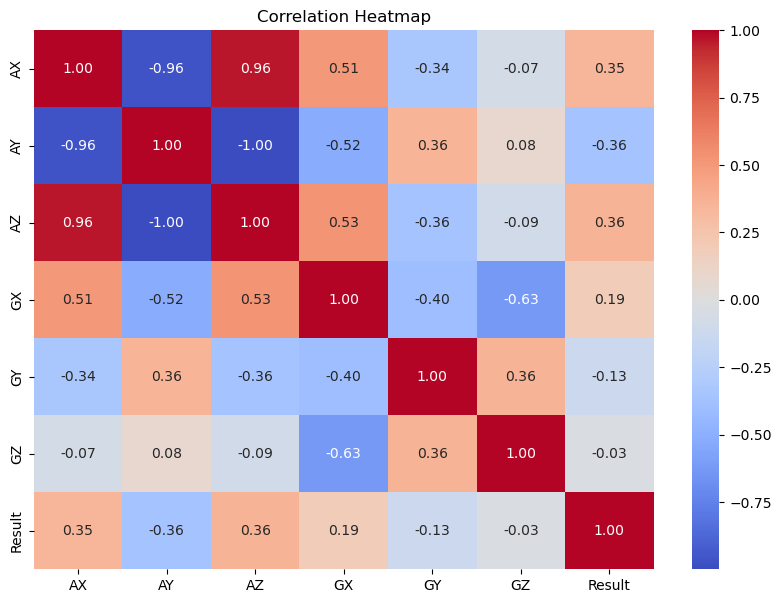

In [8]:
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

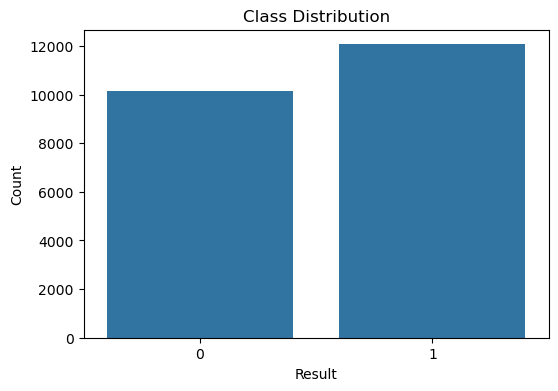

Result
1    12067
0    10158
Name: count, dtype: int64

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Result")
plt.title("Class Distribution")
plt.xlabel("Result")
plt.ylabel("Count")
plt.show()

df["Result"].value_counts()

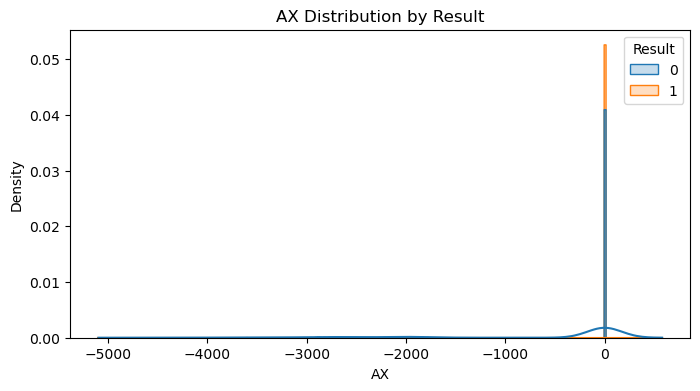

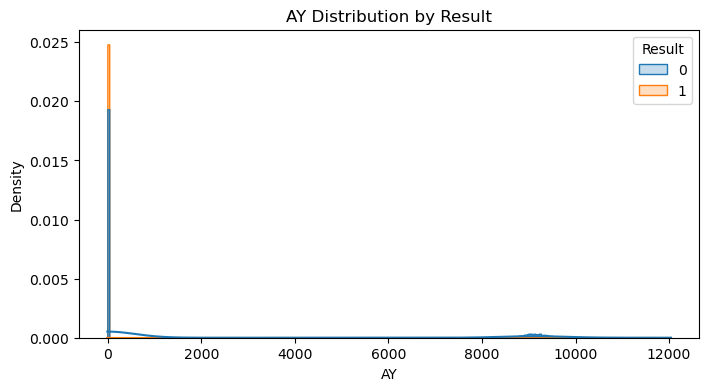

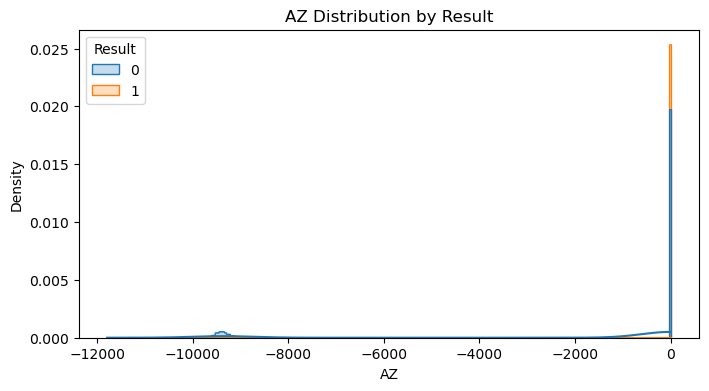

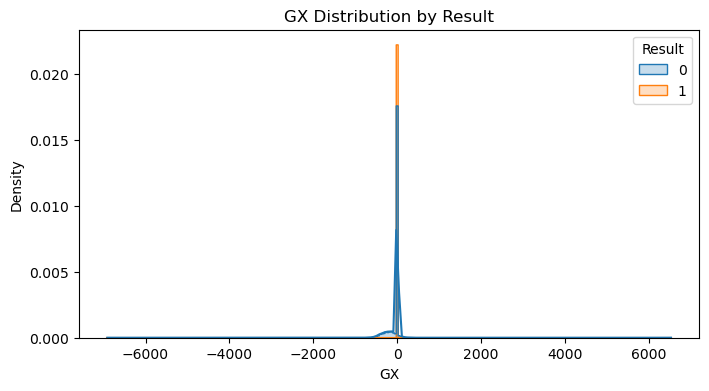

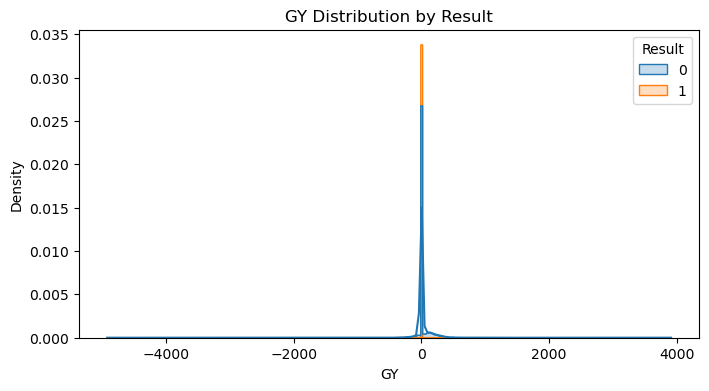

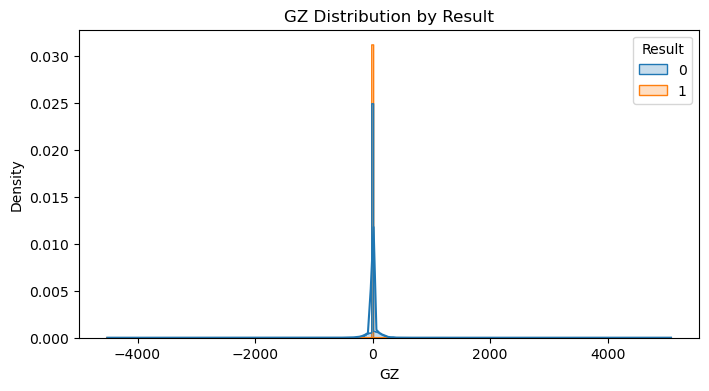

In [10]:
features = ["AX", "AY", "AZ", "GX", "GY", "GZ"]

for col in features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, hue="Result", kde=True, element="step", stat="density", common_norm=False)
    plt.title(f"{col} Distribution by Result")
    plt.show()

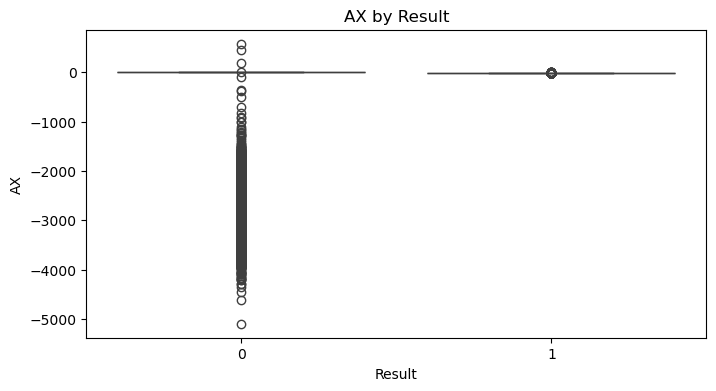

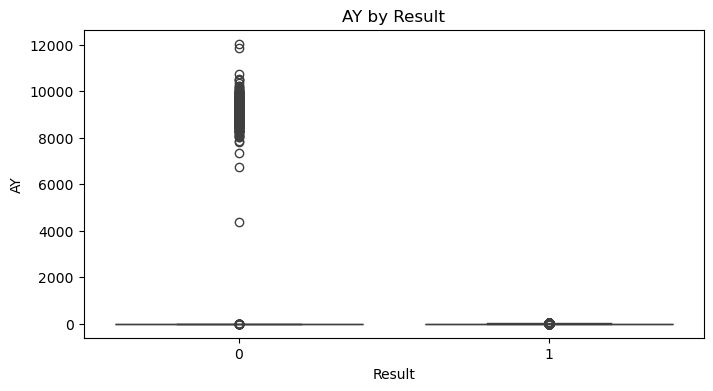

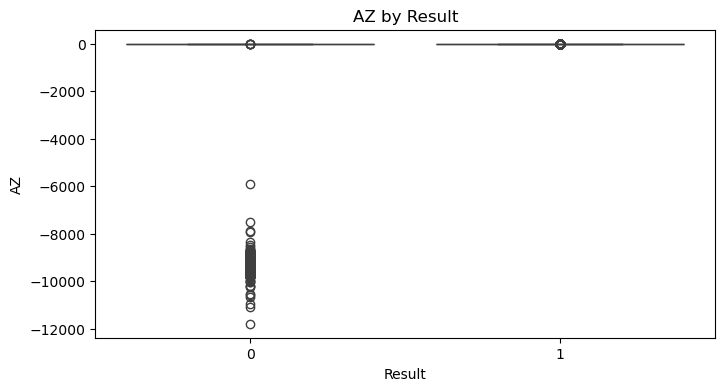

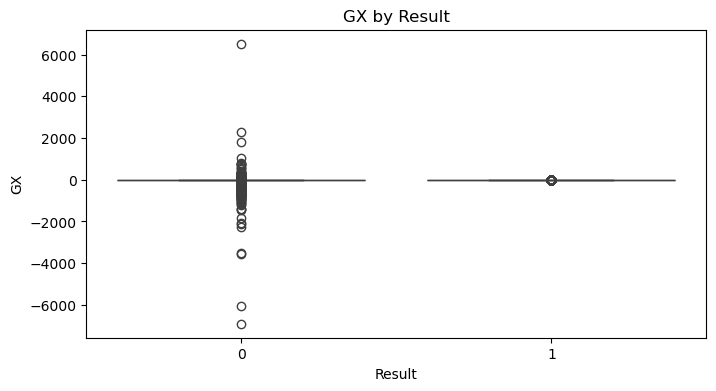

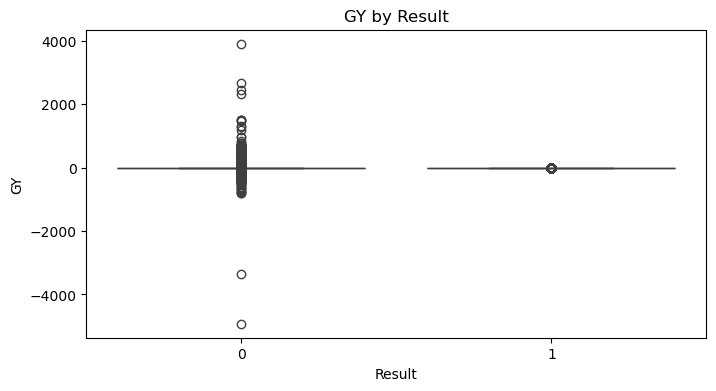

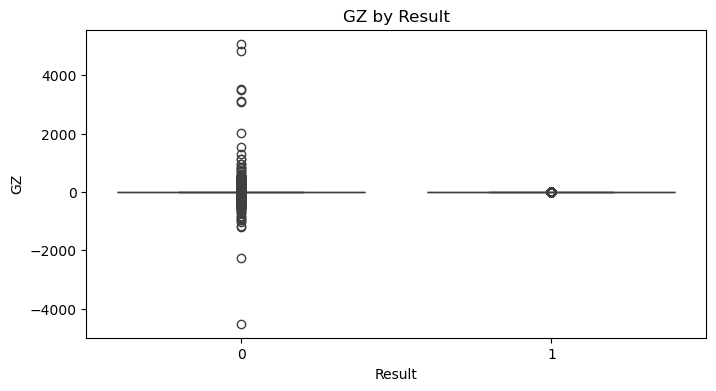

In [11]:
for col in features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x="Result", y=col)
    plt.title(f"{col} by Result")
    plt.show()

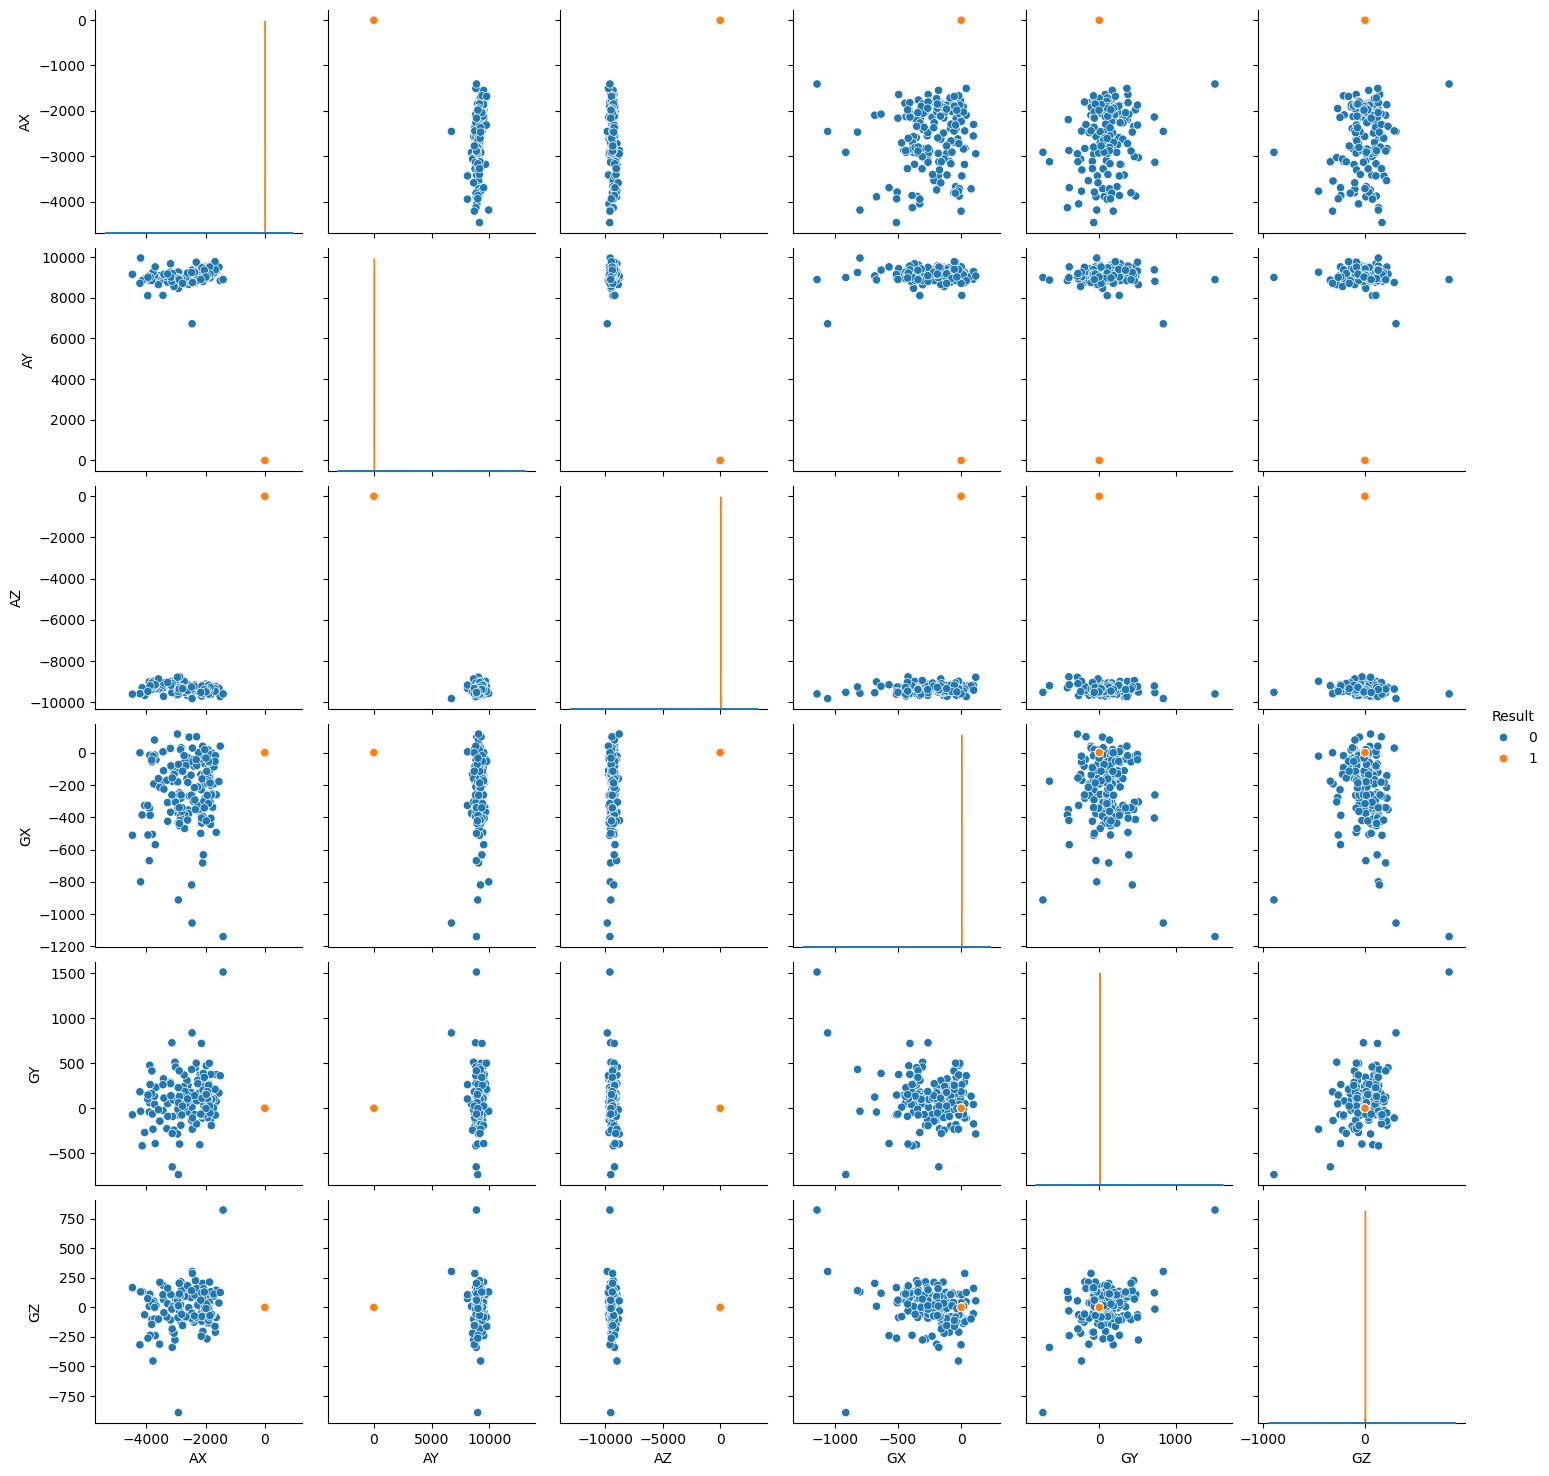

In [12]:
sample_df = df.sample(1500, random_state=42)
sns.pairplot(sample_df, vars=features, hue="Result")
plt.show()

# **Prepare Train&Test splits  for model**

In [13]:
X = df.drop("Result", axis=1)
y = df["Result"]

X.shape, y.shape

((22225, 6), (22225,))

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((17780, 6), (4445, 6), (17780,), (4445,))

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pd.DataFrame(X_train_scaled, columns=X.columns).head()

,AX,AY,AZ,GX,GY,GZ
0,0.319408,-0.332319,0.331566,0.178814,-0.112731,-0.028490
1,0.319003,-0.332134,0.331684,0.179359,-0.112974,-0.029169
2,0.318559,-0.332476,0.331525,0.179256,-0.113769,-0.027919
3,-3.065772,3.035234,-3.081036,0.740116,1.373638,0.565714
4,0.326503,-0.335046,0.336138,0.178142,-0.112940,-0.028253


# **Grid Search for Best Hyper parameters for the model**

In [16]:
import time
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# تحويل للـ numpy arrays
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()

# ----- Sampling لتجربة سريعة (اختياري) -----
sample_size = 50000
if len(X_train_np) > sample_size:
    sample_idx = np.random.choice(len(X_train_np), size=sample_size, replace=False)
    X_sample = X_train_np[sample_idx]
    y_sample = y_train_np[sample_idx]
else:
    X_sample = X_train_np
    y_sample = y_train_np

# ----- Pipeline ----- 
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True, random_state=42))  # <--- probability=True
])

# ----- Grid للـ hyperparameters -----
param_grid = {
    "model__kernel": ["rbf"],       # خليها rbf فقط
    "model__C": [0.1, 1],           # اختيارات قليلة لتسريع
    "model__gamma": ["scale"],      # اختيارات قليلة
    "model__class_weight": [None, "balanced"]
}

# ----- GridSearchCV مع parallelization -----
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="recall",
    cv=3,           # 3-fold
    verbose=2,
    n_jobs=-1
)

# ----- Fit على الـ sample -----
start_time = time.time()
grid_search.fit(X_sample, y_sample)
end_time = time.time()

print("\nBest params:", grid_search.best_params_)
print("Best recall score:", grid_search.best_score_)
print(f"Elapsed time: {end_time - start_time:.2f} seconds")

# ----- بعد اختيار أفضل params، اعمل fit على كل البيانات -----
best_pipeline = grid_search.best_estimator_
best_pipeline.fit(X_train_np, y_train_np)
print("Final model trained on full dataset with predict_proba ready.")


Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best params: {'model__C': 0.1, 'model__class_weight': None, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best recall score: 1.0
Elapsed time: 823.99 seconds
Final model trained on full dataset with predict_proba ready.


In [17]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'model__C': 0.1, 'model__class_weight': None, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
1.0


# **Select best model**

In [18]:
best_model = grid_search.best_estimator_
best_model

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,0.1
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [19]:
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_acc, test_acc

c:\Users\Abdelatef Osama\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
c:\Users\Abdelatef Osama\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


(0.643082114735658, 0.6476940382452193)

In [20]:
print(classification_report(y_test, y_test_pred, target_names=["No Tremor", "Tremor"]))

              precision    recall  f1-score   support

   No Tremor       1.00      0.23      0.37      2032
      Tremor       0.61      1.00      0.76      2413

    accuracy                           0.65      4445
   macro avg       0.80      0.61      0.56      4445
weighted avg       0.79      0.65      0.58      4445



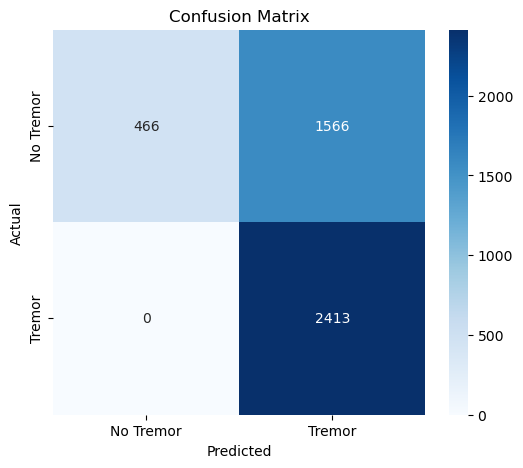

In [21]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Tremor", "Tremor"], yticklabels=["No Tremor", "Tremor"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **Store Model**

In [22]:
joblib.dump(best_model, "tremor_model.pkl")

['tremor_model.pkl']

# **Test Function**

In [23]:
def predict_tremor_batch(sensor_list, model = best_model):
    results = []

    for reading in sensor_list:
        input_df = pd.DataFrame([reading], columns=["AX", "AY", "AZ", "GX", "GY", "GZ"])

        prediction = model.predict(input_df)[0]
        probabilities = model.predict_proba(input_df)[0]

        no_tremor_prob = float(probabilities[0] * 100)
        tremor_prob = float(probabilities[1] * 100)

        result_label = "Tremor" if prediction == 1 else "No Tremor"
        confidence = tremor_prob if prediction == 1 else no_tremor_prob

        results.append({
            "AX": reading[0],
            "AY": reading[1],
            "AZ": reading[2],
            "GX": reading[3],
            "GY": reading[4],
            "GZ": reading[5],
            "Prediction": result_label,
            "Confidence %": round(confidence, 2),
            "No Tremor %": round(no_tremor_prob, 2),
            "Tremor %": round(tremor_prob, 2)
        })

    return pd.DataFrame(results)

# **Import Model**

In [24]:
import joblib

joblib.dump(best_pipeline, r"C:\Users\Abdelatef Osama\Desktop\Grad_Project\tremor_model.pkl")
print("Model saved ✅")


Model saved ✅


# **Test Input sample**

In [25]:
sensor_data = [
    [150, 800, -400, 900, -2000, 600],
    [-7064, 13280, -2152, -771, -105, 461],
    [200, 950, -500, 1200, -2500, 850]
]

result_df = predict_tremor_batch(sensor_data)
print(result_df)

     AX     AY    AZ    GX    GY   GZ Prediction  Confidence %  No Tremor %  \
0   150    800  -400   900 -2000  600  No Tremor         100.0        100.0   
1 -7064  13280 -2152  -771  -105  461  No Tremor         100.0        100.0   
2   200    950  -500  1200 -2500  850  No Tremor         100.0        100.0   

   Tremor %  
0       0.0  
1       0.0  
2       0.0  


c:\Users\Abdelatef Osama\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
c:\Users\Abdelatef Osama\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
c:\Users\Abdelatef Osama\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
c:\Users\Abdelatef Osama\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
c:\Users\Abdelatef Osama\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
c:\Users\Abdelatef Osama\anaconda3\Lib\site-packag

In [26]:
import pandas as pd

# القراءات المستخرجة من الصورة (7 صفوف و 6 أعمدة)
sensor_data = [
    [-15.88, 0.33, 8.3, -0.22, -0.07, -0.02],
    [-16.11, 0.57, 7.68, 0.01, -0.08, 0.14],
    [-16.62, 0.25, 7.91, -0.04, -0.1, 0.06],
    [-15.64, 0.4, 7.41, -0.1, 0.12, -0.02],
    [-16.09, 1.91, 7.81, 0.08, -0.31, 0.35],
    [-17.23, 0.62, 7.27, -0.09, 0.08, 0.15],
    [-15.73, 1.73, 7.13, -0.14, -0.04, -0.13]
]

# استدعاء الدالة الخاصة بك لمعالجة البيانات الجديدة
result_df = predict_tremor_batch(sensor_data)

# طباعة النتيجة
print(result_df)

c:\Users\Abdelatef Osama\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
c:\Users\Abdelatef Osama\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
c:\Users\Abdelatef Osama\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
c:\Users\Abdelatef Osama\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
c:\Users\Abdelatef Osama\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
c:\Users\Abdelatef Osama\anaconda3\Lib\site-packag

      AX    AY    AZ    GX    GY    GZ Prediction  Confidence %  No Tremor %  \
0 -15.88  0.33  8.30 -0.22 -0.07 -0.02     Tremor         100.0          0.0   
1 -16.11  0.57  7.68  0.01 -0.08  0.14     Tremor         100.0          0.0   
2 -16.62  0.25  7.91 -0.04 -0.10  0.06     Tremor         100.0          0.0   
3 -15.64  0.40  7.41 -0.10  0.12 -0.02     Tremor         100.0          0.0   
4 -16.09  1.91  7.81  0.08 -0.31  0.35     Tremor         100.0          0.0   
5 -17.23  0.62  7.27 -0.09  0.08  0.15     Tremor         100.0          0.0   
6 -15.73  1.73  7.13 -0.14 -0.04 -0.13     Tremor         100.0          0.0   

   Tremor %  
0     100.0  
1     100.0  
2     100.0  
3     100.0  
4     100.0  
5     100.0  
6     100.0  
